Collisions: (503475, 44)
Vehicles: (920692, 32)
Casualties: (640522, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503475 entries, 0 to 503474
Data columns (total 44 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   collision_index                                   503475 non-null  object 
 1   collision_year                                    503475 non-null  int64  
 2   collision_ref_no                                  503475 non-null  object 
 3   location_easting_osgr                             503410 non-null  float64
 4   location_northing_osgr                            503410 non-null  float64
 5   longitude                                         503410 non-null  float64
 6   latitude                                          503410 non-null  float64
 7   police_force                                      503475 non-null  int64  
 8   collision_s

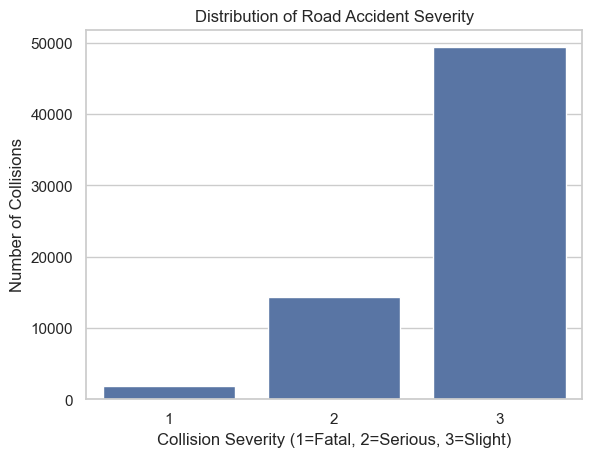

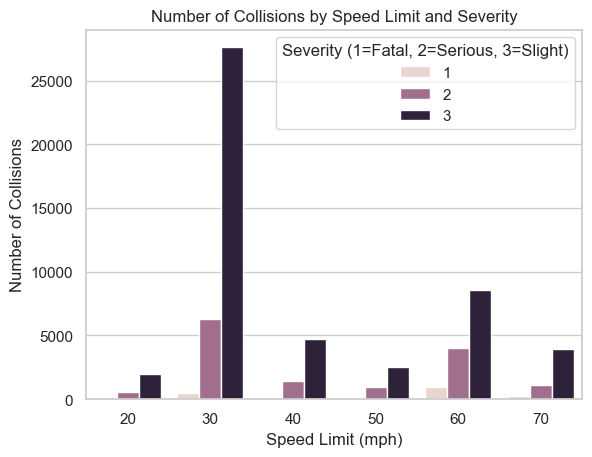

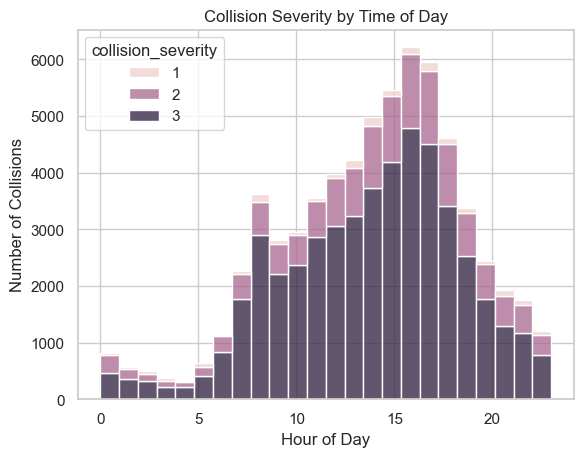

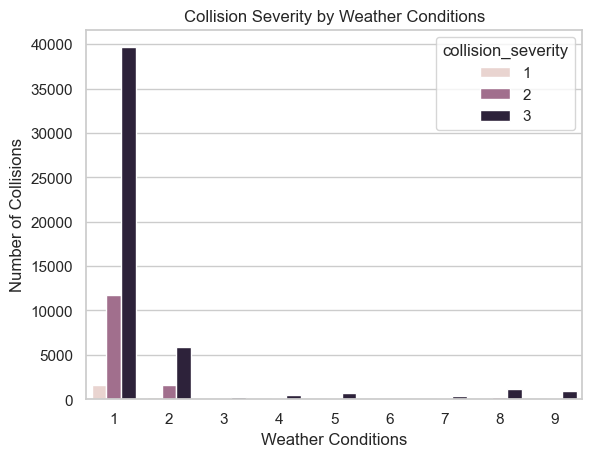

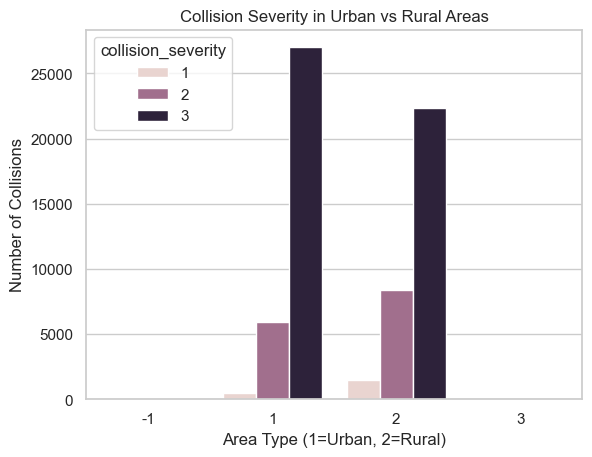

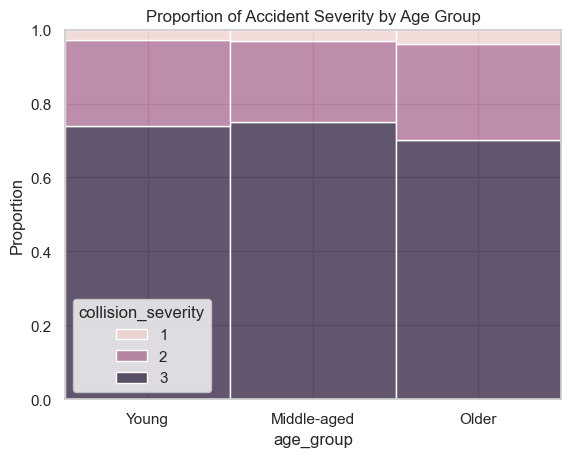

(52527, 33)
(13132, 33)
(52527,)
(13132,)
              precision    recall  f1-score   support

           0       0.76      1.00      0.86      9931
           1       0.54      0.02      0.03      3201

    accuracy                           0.76     13132
   macro avg       0.65      0.51      0.45     13132
weighted avg       0.71      0.76      0.66     13132

              precision    recall  f1-score   support

           0       0.82      0.60      0.69      9931
           1       0.32      0.59      0.42      3201

    accuracy                           0.60     13132
   macro avg       0.57      0.60      0.56     13132
weighted avg       0.70      0.60      0.63     13132

              precision    recall  f1-score   support

           0       0.76      0.99      0.86      9931
           1       0.53      0.02      0.04      3201

    accuracy                           0.76     13132
   macro avg       0.64      0.51      0.45     13132
weighted avg       0.70      0.7

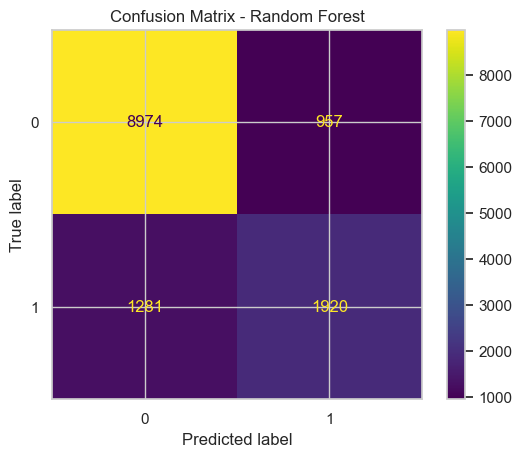

                 Feature  Importance
1          age_of_driver    0.370430
2                   hour    0.270725
0            speed_limit    0.068649
9   weather_conditions_2    0.024468
29       sex_of_driver_2    0.018864
7          day_of_week_6    0.017725
22    light_conditions_4    0.017264
6          day_of_week_5    0.017169
19           road_type_6    0.016012
5          day_of_week_4    0.016000


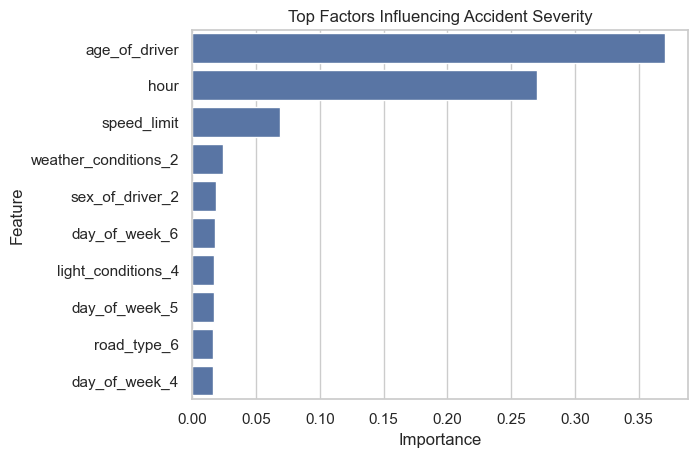

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

collisions = pd.read_csv(
    r"C:\Users\Nalli\OneDrive\Pictures\Desktop\Viveks Project\dft-road-casualty-statistics-collision-last-5-years(1).csv"
)

vehicles = pd.read_csv(
    r"C:\Users\Nalli\OneDrive\Pictures\Desktop\Viveks Project\dft-road-casualty-statistics-vehicle-last-5-years(1).csv",
    low_memory=False
)

casualties = pd.read_csv(
    r"C:\Users\Nalli\OneDrive\Pictures\Desktop\Viveks Project\dft-road-casualty-statistics-casualty-last-5-years(1).csv"
)

print("Collisions:", collisions.shape)
print("Vehicles:", vehicles.shape)
print("Casualties:", casualties.shape)

collisions.info()
vehicles.info()
casualties.info()

collision_vehicle = pd.merge(
    collisions,
    vehicles,
    on="collision_index",
    how="inner"
)

full_data = pd.merge(
    collision_vehicle,
    casualties,
    on="collision_index",
    how="inner"
)

print("Merged dataset:", full_data.shape)

data = full_data[
    [
        'collision_severity',
        'day_of_week',
        'time',
        'weather_conditions',
        'road_type',
        'speed_limit',
        'light_conditions',
        'urban_or_rural_area',
        'age_of_driver',
        'sex_of_driver'
    ]
]

data = data.dropna()

data['hour'] = pd.to_datetime(
    data['time'], format='%H:%M', errors='coerce'
).dt.hour

data = data.dropna(subset=['hour'])

data.info()

print(data['collision_severity'].value_counts())

data['age_group'] = pd.cut(
    data['age_of_driver'],
    bins=[0, 25, 60, 100],
    labels=['Young', 'Middle-aged', 'Older']
)

#Plot 1 
sns.countplot(x='collision_severity', data=data)
plt.title("Distribution of Road Accident Severity")
plt.xlabel("Collision Severity (1=Fatal, 2=Serious, 3=Slight)")
plt.ylabel("Number of Collisions")
plt.show()

#Plot 2
sns.countplot(x='speed_limit', hue='collision_severity', data=data)
plt.title("Number of Collisions by Speed Limit and Severity")
plt.xlabel("Speed Limit (mph)")
plt.ylabel("Number of Collisions")
plt.legend(title="Severity (1=Fatal, 2=Serious, 3=Slight)")
plt.show()

#plot 3
sns.histplot(data=data, x='hour', hue='collision_severity', bins=24, multiple='stack')
plt.title("Collision Severity by Time of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Collisions")
plt.show()

#Plot 4
sns.countplot(x='weather_conditions', hue='collision_severity', data=data)
plt.title("Collision Severity by Weather Conditions")
plt.xlabel("Weather Conditions")
plt.ylabel("Number of Collisions")
plt.show()

#Plot 5
sns.countplot(x='urban_or_rural_area', hue='collision_severity', data=data)
plt.title("Collision Severity in Urban vs Rural Areas")
plt.xlabel("Area Type (1=Urban, 2=Rural)")
plt.ylabel("Number of Collisions")
plt.show()

#Plot 6
sns.histplot(
    data=data,
    x='age_group',
    hue='collision_severity',
    multiple='fill'
)
plt.title("Proportion of Accident Severity by Age Group")
plt.ylabel("Proportion")
plt.show()

data['severe_accident'] = data['collision_severity'].apply(
    lambda x: 1 if x in [1,2] else 0
)

data = data.drop(columns=['time'])

categorical_cols = [
    'day_of_week',
    'weather_conditions',
    'road_type',
    'light_conditions',
    'urban_or_rural_area',
    'sex_of_driver',
    'age_group'   
]

data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

X = data.drop(columns=['collision_severity','severe_accident'])
y = data['severe_accident']

#Training and testing 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


#Logistic Regression Model
#Model 1
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

#####Logistic Regression(Balanced)#####
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))


#Decision Tree Model
#Model 2
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

print(classification_report(y_test, dt_predictions))

#####Decision Tree(Balanced)#####
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

dt_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

print(classification_report(y_test, dt_predictions))



#Random Forest Model
#Model 3
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print(classification_report(y_test, rf_predictions))

#Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

#Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

# Plot Feature Importance
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)
plt.title("Top Factors Influencing Accident Severity")
plt.show()


Collisions: (503475, 44)
Vehicles: (920692, 32)
Casualties: (640522, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503475 entries, 0 to 503474
Data columns (total 44 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   collision_index                                   503475 non-null  object 
 1   collision_year                                    503475 non-null  int64  
 2   collision_ref_no                                  503475 non-null  object 
 3   location_easting_osgr                             503410 non-null  float64
 4   location_northing_osgr                            503410 non-null  float64
 5   longitude                                         503410 non-null  float64
 6   latitude                                          503410 non-null  float64
 7   police_force                                      503475 non-null  int64  
 8   collision_s

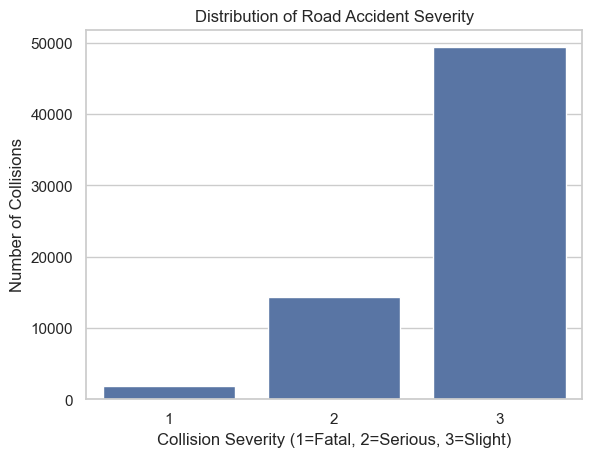

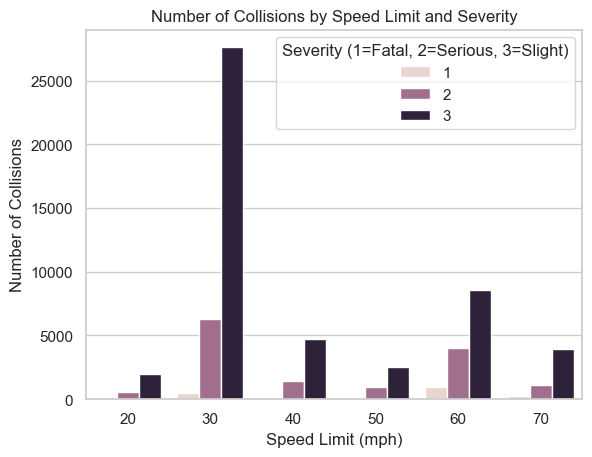

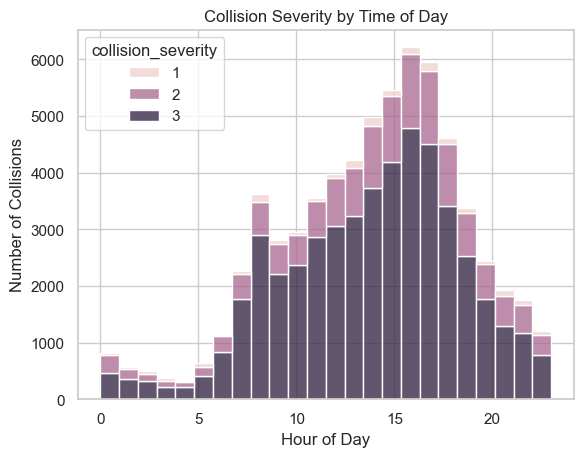

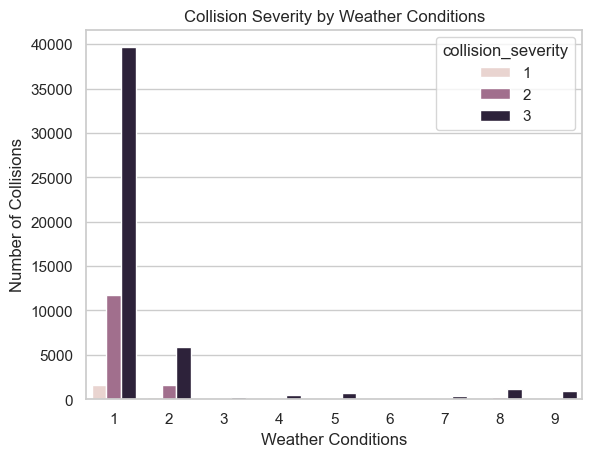

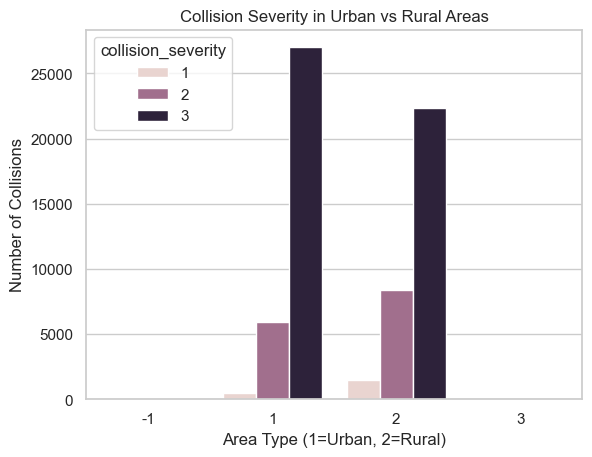

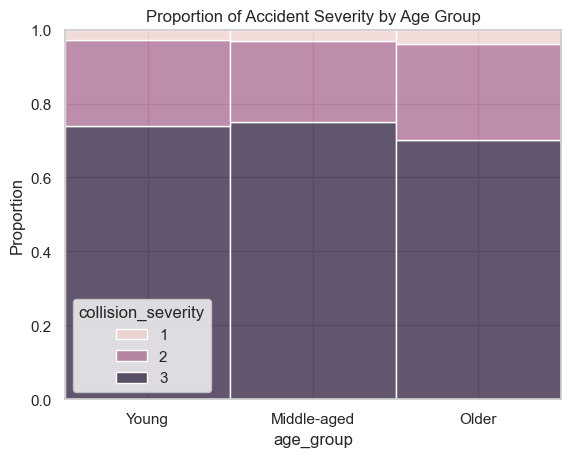

(52527, 33)
(13132, 33)
(52527,)
(13132,)
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       360
           1       0.45      0.00      0.00      2841
           2       0.76      1.00      0.86      9931

    accuracy                           0.76     13132
   macro avg       0.40      0.33      0.29     13132
weighted avg       0.67      0.76      0.65     13132

              precision    recall  f1-score   support

           0       0.06      0.63      0.11       360
           1       0.25      0.24      0.24      2841
           2       0.82      0.56      0.67      9931

    accuracy                           0.49     13132
   macro avg       0.38      0.48      0.34     13132
weighted avg       0.68      0.49      0.56     13132

              precision    recall  f1-score   support

           0       1.00      0.01      0.01       360
           1       0.68      0.02      0.03      2841
           2       0.76      1.00

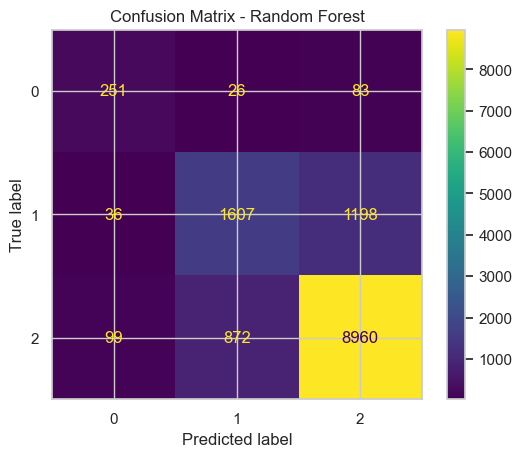

                 Feature  Importance
1          age_of_driver    0.328768
2                   hour    0.265518
0            speed_limit    0.082191
9   weather_conditions_2    0.027931
29       sex_of_driver_2    0.022145
7          day_of_week_6    0.020317
6          day_of_week_5    0.019452
22    light_conditions_4    0.018692
4          day_of_week_3    0.018268
3          day_of_week_2    0.018156


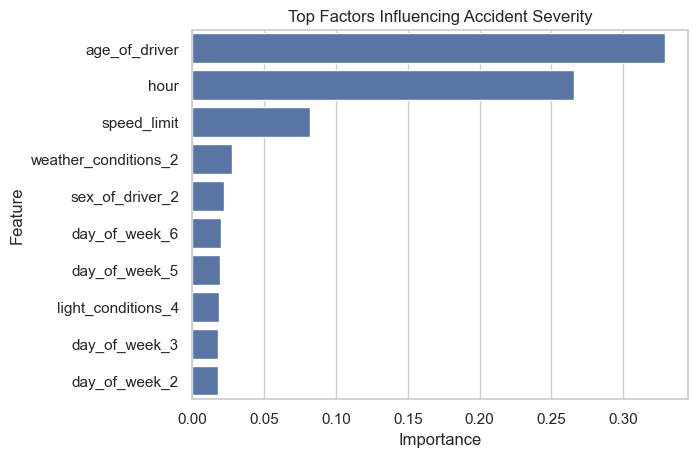

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

collisions = pd.read_csv(
    r"C:\Users\Nalli\OneDrive\Pictures\Desktop\Viveks Project\dft-road-casualty-statistics-collision-last-5-years(1).csv"
)

vehicles = pd.read_csv(
    r"C:\Users\Nalli\OneDrive\Pictures\Desktop\Viveks Project\dft-road-casualty-statistics-vehicle-last-5-years(1).csv",
    low_memory=False
)

casualties = pd.read_csv(
    r"C:\Users\Nalli\OneDrive\Pictures\Desktop\Viveks Project\dft-road-casualty-statistics-casualty-last-5-years(1).csv"
)

print("Collisions:", collisions.shape)
print("Vehicles:", vehicles.shape)
print("Casualties:", casualties.shape)

collisions.info()
vehicles.info()
casualties.info()

collision_vehicle = pd.merge(
    collisions,
    vehicles,
    on="collision_index",
    how="inner"
)

full_data = pd.merge(
    collision_vehicle,
    casualties,
    on="collision_index",
    how="inner"
)

print("Merged dataset:", full_data.shape)

data = full_data[
    [
        'collision_severity',
        'day_of_week',
        'time',
        'weather_conditions',
        'road_type',
        'speed_limit',
        'light_conditions',
        'urban_or_rural_area',
        'age_of_driver',
        'sex_of_driver'
    ]
]

data = data.dropna()

data['hour'] = pd.to_datetime(
    data['time'], format='%H:%M', errors='coerce'
).dt.hour

data = data.dropna(subset=['hour'])

data.info()

print(data['collision_severity'].value_counts())

data['age_group'] = pd.cut(
    data['age_of_driver'],
    bins=[0, 25, 60, 100],
    labels=['Young', 'Middle-aged', 'Older']
)

# Plot 1 
sns.countplot(x='collision_severity', data=data)
plt.title("Distribution of Road Accident Severity")
plt.xlabel("Collision Severity (1=Fatal, 2=Serious, 3=Slight)")
plt.ylabel("Number of Collisions")
plt.show()

# Plot 2
sns.countplot(x='speed_limit', hue='collision_severity', data=data)
plt.title("Number of Collisions by Speed Limit and Severity")
plt.xlabel("Speed Limit (mph)")
plt.ylabel("Number of Collisions")
plt.legend(title="Severity (1=Fatal, 2=Serious, 3=Slight)")
plt.show()

# Plot 3
sns.histplot(data=data, x='hour', hue='collision_severity', bins=24, multiple='stack')
plt.title("Collision Severity by Time of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Collisions")
plt.show()

# Plot 4
sns.countplot(x='weather_conditions', hue='collision_severity', data=data)
plt.title("Collision Severity by Weather Conditions")
plt.xlabel("Weather Conditions")
plt.ylabel("Number of Collisions")
plt.show()

# Plot 5
sns.countplot(x='urban_or_rural_area', hue='collision_severity', data=data)
plt.title("Collision Severity in Urban vs Rural Areas")
plt.xlabel("Area Type (1=Urban, 2=Rural)")
plt.ylabel("Number of Collisions")
plt.show()

#Plot 6
sns.histplot(
    data=data,
    x='age_group',
    hue='collision_severity',
    multiple='fill'
)
plt.title("Proportion of Accident Severity by Age Group")
plt.ylabel("Proportion")
plt.show()


data = data.drop(columns=['time'])

categorical_cols = [
    'day_of_week',
    'weather_conditions',
    'road_type',
    'light_conditions',
    'urban_or_rural_area',
    'sex_of_driver',
    'age_group'   
]

data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

X = data.drop(columns=['collision_severity'])
y = data['collision_severity'] - 1

# Training and testing 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


#Logistic Regression Model
#Model 1
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=2000)

model.fit(X_train_scaled, y_train)
predictions = model.predict(X_test_scaled)

print(classification_report(y_test, predictions, zero_division=0))

##### Logistic Regression (Balanced) #####
model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)

model.fit(X_train_scaled, y_train)
predictions = model.predict(X_test_scaled)

print(classification_report(y_test, predictions, zero_division=0))


#Decision Tree Model
#Model 2
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)

print(classification_report(y_test, dt_predictions, zero_division=0))

##### Decision Tree (Balanced) #####
dt_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)

print(classification_report(y_test, dt_predictions, zero_division=0))

#Random Forest Model
#Model 3
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

print(classification_report(y_test, rf_predictions, zero_division=0))

#Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

#Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

# Plot Feature Importance
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)
plt.title("Top Factors Influencing Accident Severity")
plt.show()
